# 트리 · GNN 통합 — 코드 한 파일 + 맨 끝에 성능 비교 시각화

손은총 · 자금세탁소 · 2026-09-28 · HI-Large · 상태 **제안·미결**(결정은 팀 다섯 명이 함께 한다)

노트북 **25(트리) · 26(GNN 유형구분) · 27(GNN 9클래스)** 를 한 파일로 모으고, **맨 끝 §4 에 두 모델 성능 비교와 그림 5장**을 붙였다.

## 실행 결과는 건드리지 않는다

- §1~§3 은 전부 **기본값 `False` 로 꺼져 있다.** 켜면 몇 시간이 걸리고 `results/T8_*·T9_*·T10_*.csv` 를 **덮어쓴다.**
- §4(비교·시각화)는 **결과 파일을 읽기만 한다.** 그래서 §1~§3 이 꺼져 있어도 돈다 — 이 파일을 열면 바로 §4 의 표와 그림이 보인다.
- §2 셀에 붙어 있는 출력은 **09-22 원본 실행 기록을 그대로 옮긴 것**이다.
- 원본 노트북 25·26·27 은 그대로 둔다. §4 의 그림은 새 폴더 `notebooks/_figs_28/` 에 저장해 09-26 보고서 그림을 덮지 않는다.

## 원본과 무엇이 다른가

`if RUN_*:` **한 줄과 그에 따른 들여쓰기뿐이다.** 되돌려서 원본과 글자까지 같은지 확인했다(`build28_part1.py`의 `guard()`).
`tree9_lib.py` · `gnn10_lib.py` · `daily_pipeline.py` 는 원래처럼 `import` 한다(라이브러리라 합치지 않았다).

## 차례

| 절 | 내용 | 원본 | 스위치 | 비용 |
|---|---|---|---|---|
| §1 | 트리 9클래스 (LightGBM · 54열) | 노트북 25 | `RUN_TREE` | 약 4~5시간 |
| §2 | GNN — 세탁 행만 유형 8종 | 노트북 26 | `RUN_GNN_유형구분` | GPU · 수 시간 |
| §3 | GNN — 9클래스 원본 거래 전부 | 노트북 27 | `RUN_GNN_9클래스` | GPU · 수 시간 |
| **§4** | **GNN vs LightGBM 비교 + 그림 5장** | 09-26 보고서 `make_figs.py` | 항상 실행 | 수 초 |

## 실행 전 필요 (§1~§3 을 켤 때만)

- `/tmp/tree9_work/` — 결합 파일 85일 + 태훈님 코드 (§1)
- `/tmp/gnn9_full/` — 하루 그래프 캐시 (§3), `_work/gnn10_cache/` (§2), CUDA GPU


In [ ]:
# ── 무엇을 돌릴지 (기본값: 전부 끔 — 기존 결과 파일을 지키기 위해) ──
RUN_TREE         = False   # §1 트리 9클래스 학습 (약 4~5시간 · results/T8_*.csv 덮어씀)
RUN_GNN_유형구분  = False   # §2 GNN 세탁행 유형구분 (GPU · results/T9_*.csv 덮어씀)
RUN_GNN_9클래스   = False   # §3 GNN 9클래스 (GPU · results/T10_*.csv 덮어씀)
# §4 비교·시각화는 스위치가 없다 — 결과 파일을 읽기만 하므로 항상 안전하게 돈다.

for _n, _v in [('RUN_TREE', RUN_TREE), ('RUN_GNN_유형구분', RUN_GNN_유형구분), ('RUN_GNN_9클래스', RUN_GNN_9클래스)]:
    print(f'{_n:18s} {_v}')
print('\n§4(비교·시각화)는 항상 실행된다 — 결과 파일만 읽는다.')

# §1 트리 9클래스 다중분류 — LightGBM  (원본: 노트북 25)

`RUN_TREE = True` 일 때만 돈다. 전체 실행 약 4~5시간이고 `results/T8_*.csv` 를 덮어쓴다.
아래 코드는 원본 `25_트리10클래스_스키마35.py` 와 **`if RUN_TREE:` 한 줄과 들여쓰기 말고는 글자 그대로 같다**.

# 25 — 트리 9클래스 다중분류 · 태훈님 고정 스키마 35개(트리 입력 54열) · LightGBM

손은총 · 2026-09-22 · 상태 "제안·미결"(수치와 위치만, 결론·다음 액션 없음)

| 항목 | 값 | 출처 |
|---|---|---|
| 입력 | 송신 노드 19(`src_`) + 수신 노드 19(`dst_`) + 엣지 16 = 54열, 스키마 순서 | `Final_preprocess/aml_feature_schema.csv`(09-22 수령, 태훈님 고정 목록) |
| 값 | 09-21 노트북 20 이 태훈님 코드로 만든 62열 결합 파일에서 54열만 고른다(다시 계산하지 않음) | `/tmp/tree9_work/joined`(백업 `_work/tree9_20260921/`) |
| 라벨 | **9클래스**: 0~7 패턴 8종 · 8 = 정상. **패턴 밖 세탁(is_pos=1 이고 패턴 없음)은 학습·평가에서 뺀다**(정상으로 재라벨하지 않음). 평가 때 그 행을 모델이 무엇으로 예측했는지만 따로 적는다 | 사용자 결정 09-22 04:5x(09-01 팀 기록 "학습에서 제거, 재라벨 안 함"과 같음). 같은 날 앞선 10클래스 결정을 대체 |
| 서비스 구조 | 이진분류(태훈님)와 다중분류가 같은 원본 거래를 **동시에** 받는다 → 다중분류도 정상 포함 원본 거래 전부로 학습·평가 | 사용자 09-22 |
| 가중치 | 패턴 세탁 행 300 · 정상 1 | 사용자 결정 (가) 09-21 · GNN_REPORT 211·216줄 |
| 분할 | train 08-08~09-27 · val 09-28~10-14 · test 10-15~10-31 | 태훈님 GNN_REPORT §6.2 |
| 트리 설정 | 최대 300 rounds · patience 20 · 깊이 6 · lr 0.1 · max_bin 63 · threads 2 · num_leaves 31 · 다운샘플링·튜닝 없음 | GNN_REPORT 214·216줄 |
| 모델 선택 | val macro-AP(9클래스 one-vs-rest AP 평균)가 가장 높은 round | 사용자 결정 (나) 09-21 |

- 노트북 21(9클래스·62열, 미실행)을 바탕으로 만들었다. 21 은 고치지 않았다. 21 과 다른 것: 입력 54열, 패턴 밖 세탁 제외(21 은 정상 클래스에 넣었음), 작업 파일·결과 파일 이름(`nb25_9c/`, `T8_*`).
- 09-22 01:4x 첫 전체 실행(10클래스)은 메모리 감시(mem_guard)에 걸려 학습 전 중단 → 결과 없음. 이 판은 9클래스로 바꿔 다시 돈다.
- 행·열을 뽑는 옵션은 전부 끈다(무작위 금지). 패턴 밖 세탁을 뺀 나머지 행은 기간 안 전부, 날짜 순서대로 넘긴다. 구간 경계는 학습 행을 같은 간격으로 건너뛴 20만 행으로 정한다(뽑기 아님).
- val 점수는 모델 밖에서 round 마다 새 트리 점수만 더해 macro-AP 를 잰다(노트북 19 에서 누적 점수 = 전체 예측 확인). test 는 선택이 끝난 뒤 한 번만 채점한다.
- 이진 지표도 같이 적는다: 세탁 여부 AP(점수 = 1 − P(정상), 정답 = 패턴 세탁), argmax 가 정상이 아니면 "세탁" 으로 본 정밀도·재현율·F1. 모두 패턴 밖 세탁을 뺀 행 기준.
- `TREE10_SMOKE=1` 이면 작은 기간(08-08 학습 · 08-09 검증·시험, 3 round)으로 코드만 시험한다.

In [ ]:
if RUN_TREE:
    import sys, os, json, time, gc, threading
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA')
    import numpy as np, pandas as pd
    import tree9_lib as L
    import lightgbm as lgb
    from sklearn.metrics import average_precision_score
    SMOKE = os.environ.get('TREE10_SMOKE') == '1'
    a, _ = L.mem('시작'); assert SMOKE or a < 6, '다른 무거운 작업이 돌고 있다'
    L.check_disk()
    TAG = 'nb25_9c_smoke' if SMOKE else 'nb25_9c'
    WD = L.WORK / TAG; WD.mkdir(exist_ok=True)                                   # 큰 중간 파일(/tmp — 컨테이너를 다시 만들면 사라짐)
    MD = L.EDA / '_work' / ('tree9c_schema35_smoke' if SMOKE else 'tree9c_schema35'); MD.mkdir(parents=True, exist_ok=True)   # 모델·결과 json
    RP = 'T8s_' if SMOKE else 'T8_'                                              # 결과표 접두사
    guard = L.AnonGuard(23.0, marker=WD / 'ANON_GUARD.txt').start()              # 23 GiB — 09-22 mem_guard 를 80%(21.9 GiB)로 올려 돌리므로 컨테이너 한도 27.3 GiB 전에 이 노트북이 먼저 멈추게
    if SMOKE:
        JD = L.WORK / 'joined_small'
        DAYS = {'train': ['2022-08-08'], 'val': ['2022-08-09'], 'test': ['2022-08-09']}
        MAX_ROUNDS, PATIENCE = 3, 2
    else:
        JD = L.WORK / 'joined'
        DAYS = {s: L.days_of(s) for s in ['train', 'val', 'test']}
        MAX_ROUNDS, PATIENCE = 300, 20                                           # 태훈님 GNN_REPORT 216줄
    CH = 500_000                                                                 # 예측 조각 크기(값에 영향 없음)

    # 스키마 → 54열(62열 결합 파일에서 고를 열 번호)
    SCH = pd.read_csv('/workspace/Final_preprocess/aml_feature_schema.csv', encoding='utf-8-sig')
    NODE19 = [L.NAME_FIX.get(f, f) for f in SCH.query("tensor=='node'").sort_values('col_index')['feature']]
    EDGE16 = list(SCH.query("tensor=='edge'").sort_values('col_index')['feature'])
    assert len(NODE19) == 19 and len(EDGE16) == 16
    F54 = ['src_' + f for f in NODE19] + ['dst_' + f for f in NODE19] + EDGE16
    IDX = np.array([L.F62.index(f) for f in F54])                                # 없는 이름이면 여기서 멈춘다
    print('뺀 열(62 → 54):', [f for f in L.F62 if f not in F54])

    K = 9
    CLASS9 = L.CLASS_NAMES[:8] + ['정상']
    LGB_P = dict(objective='multiclass', num_class=K, learning_rate=0.1, num_leaves=31, max_depth=6, max_bin=63, num_threads=2, seed=42,
                 deterministic=True, force_col_wise=True, bagging_fraction=1.0, bagging_freq=0, feature_fraction=1.0, verbosity=-1)

    def to_y9(y9, ip, w):
        """0~7 패턴은 그대로, 정상 → 8, 패턴 밖 세탁 → −1(뺄 행). 가중치는 결합 파일 값(세탁 300 · 정상 1)을 그대로 쓰되 맞는지 확인한다."""
        assert not ((y9 < 8) & (ip != 1)).any(), '패턴 라벨인데 is_pos=0 인 행이 있다'
        assert np.array_equal(w, np.where(ip == 1, 300.0, 1.0).astype(np.float32)), '가중치가 세탁 300 · 정상 1 이 아니다'
        return np.where(y9 < 8, y9, np.where(ip == 1, -1, 8)).astype(np.int8)

    def read54(d, keep_out=False):
        """하루 → (패턴 밖을 뺀 X, y, w) [+ 패턴 밖 행의 X]."""
        X, y9, ip, w, _ = L.read_day(JD, d)
        y = to_y9(y9, ip, w); k = y >= 0
        Xk = np.ascontiguousarray(X[k][:, IDX]); out = (Xk, y[k], w[k])
        if keep_out: out += (np.ascontiguousarray(X[~k][:, IDX]),)
        del X
        return out

    def kept_rows(d):
        _, y9, ip, w, _ = L.read_day(JD, d, with_x=False)
        y = to_y9(y9, ip, w); return int((y >= 0).sum()), int((y < 0).sum())

    RC = {s: [kept_rows(d) for d in DAYS[s]] for s in DAYS}
    NROW = {s: [r[0] for r in RC[s]] for s in DAYS}
    N = {s: int(sum(NROW[s])) for s in DAYS}; NOUT = {s: int(sum(r[1] for r in RC[s])) for s in DAYS}
    print('남기는 행', N, '· 뺀 패턴 밖 세탁 행', NOUT, '· SMOKE' if SMOKE else '')
    if not SMOKE:
        assert NOUT == {'train': 43_095, 'val': 16_691, 'test': 17_063}, '패턴 밖 세탁 건수가 09-21 기록(세션상태_20260921)과 다르다'

## 1) val·test 를 예측용 원시 파일(float32, 54열, 패턴 밖 제외)로 한 번만 만든다 + 분할별 클래스 건수
패턴 밖 세탁 행은 따로 작은 파일에 둔다(평가에는 안 쓰고, 모델이 무엇으로 예측했는지만 적는다).

In [ ]:
if RUN_TREE:
    def build_raw(split):
        fx = WD / f'{split}_X54.f32'
        if fx.exists() and (WD / f'{split}_y9.npy').exists() and (WD / f'{split}_out_X54.npy').exists(): return
        ys, outs, n_nan = [], [], 0
        with open(fx, 'wb') as g:
            for d in DAYS[split]:
                X, y, _, Xo = read54(d, keep_out=True); n_nan += int(np.isnan(X).sum()) + int(np.isnan(Xo).sum()); X.tofile(g); ys.append(y); outs.append(Xo); del X
        np.save(WD / f'{split}_y9.npy', np.concatenate(ys)); np.save(WD / f'{split}_out_X54.npy', np.concatenate(outs))
        L.drop_cache(fx); print(split, 'NaN 칸', n_nan); assert n_nan == 0
    for s in ['val', 'test']: build_raw(s)
    Y = {s: np.load(WD / f'{s}_y9.npy') for s in ['val', 'test']}; XOUT = {s: np.load(WD / f'{s}_out_X54.npy') for s in ['val', 'test']}
    assert all(len(Y[s]) == N[s] and len(XOUT[s]) == NOUT[s] for s in ['val', 'test'])
    cnt = pd.DataFrame({s: np.bincount(Y[s], minlength=K) for s in ['val', 'test']}, index=CLASS9)
    cnt.loc['패턴 세탁 합'] = [int((Y[s] < 8).sum()) for s in ['val', 'test']]; cnt.loc['(뺀) 패턴 밖 세탁'] = [NOUT[s] for s in ['val', 'test']]
    print(cnt.to_string()); L.mem('val·test 파일')
    if not SMOKE:
        assert (cnt.loc[CLASS9, 'val'] > 0).all(), 'val 에 양성이 없는 클래스가 있다 — macro-AP 를 잴 수 없다'
        assert [int(cnt.loc['패턴 세탁 합', s]) for s in ['val', 'test']] == [L.EXPECT_POS['val'] - 16_691, L.EXPECT_POS['test'] - 17_063], '패턴 세탁 건수가 태훈님 표 − 패턴 밖과 다르다'

    def iter_raw(split):
        with open(WD / f'{split}_X54.f32', 'rb') as f:
            a = 0
            while a < N[split]:
                X = np.fromfile(f, np.float32, count=CH * 54).reshape(-1, 54); yield a, X; a += len(X)

    def macro_ap_k(S, y, chunk=4_000_000):
        """L.macro_ap_from_margin 과 같은 계산(log softmax, 뺄셈 float64 → 결과 float32)을 K 클래스로. 반환 (macro-AP, 클래스별 AP)."""
        n = len(S); lse = np.empty(n, np.float64)
        for a in range(0, n, chunk):
            b = np.asarray(S[a:a + chunk], dtype=np.float64); mx = b.max(axis=1)
            lse[a:a + chunk] = mx + np.log(np.exp(b - mx[:, None]).sum(axis=1)); del b, mx
        aps = []
        for k in range(K):
            sk = np.empty(n, np.float32)
            for a in range(0, n, chunk): sk[a:a + chunk] = np.asarray(S[a:a + chunk, k], dtype=np.float64) - lse[a:a + chunk]
            aps.append(L.ap_binary(sk, y == k)); del sk
        del lse
        return (float(np.nanmean(aps)) if SMOKE else float(np.mean(aps))), aps

## 2) 학습 루프 — round 마다: 학습 → (지난 round macro-AP 받기·멈춤 판정) → 새 트리 점수를 val 에 더하기 → macro-AP 계산을 뒤에서 시작

In [ ]:
if RUN_TREE:
    def run_rounds(name, update_fn, contrib_fn):
        sfile = WD / f'{name}_valS.npy'
        S = np.lib.format.open_memmap(sfile, mode='w+', dtype=np.float32, shape=(N['val'], K)); hist, best, best_r, job, res = [], -1.0, -1, None, {}
        def ap_job(r):
            t = time.time(); m, aps = macro_ap_k(S, Y['val']); res[r] = (m, aps, time.time() - t)
        for r in range(MAX_ROUNDS):
            t0 = time.time(); guard.reset_peak() if r == 0 else None
            update_fn(r); t1 = time.time()
            if job is not None:
                job.join(); m, aps, tap = res.pop(r - 1); hist[-1].update(val_macro_ap=m, ap_sec=round(tap, 1), **{f'ap_{k}': v for k, v in enumerate(aps)})
                assert np.isfinite(m)
                if m > best: best, best_r = m, r - 1
                print(f"[{time.strftime('%H:%M:%S')}] {name} round {r-1}: val macro-AP {m:.6f} (최고 {best:.6f} @ {best_r}) · 학습 {hist[-1]['train_sec']}초 · 점수 더하기 {hist[-1]['add_sec']}초 · AP {tap:.0f}초 · anon 피크 {guard.peak_anon:.1f} GiB", flush=True)
                if (r - 1) - best_r >= PATIENCE:
                    print(f'{name}: {PATIENCE} round 동안 나아지지 않아 멈춤(마지막으로 학습한 round {r})'); break
            for a, X in iter_raw('val'): S[a:a + len(X)] += contrib_fn(r, X)
            t2 = time.time(); hist.append(dict(model=name, round=r, train_sec=round(t1 - t0, 1), add_sec=round(t2 - t1, 1), anon_peak_gib=round(guard.peak_anon, 2), rss_peak_gib=round(guard.peak_rss, 2)))
            job = threading.Thread(target=ap_job, args=(r,)); job.start()
            pd.DataFrame(hist).to_csv(WD / f'{name}_history_partial.csv', index=False)
        else:
            job.join(); m, aps, tap = res.pop(MAX_ROUNDS - 1); hist[-1].update(val_macro_ap=m, ap_sec=round(tap, 1), **{f'ap_{k}': v for k, v in enumerate(aps)})
            if m > best: best, best_r = m, MAX_ROUNDS - 1
        if job is not None and job.is_alive(): job.join()
        del S; gc.collect(); sfile.unlink(missing_ok=True)
        H = pd.DataFrame(hist); H['selected'] = H['round'] == best_r
        return H, best_r, best

    def evaluate(name, predict_fn, best_r):
        """선택한 round 로 val·test 를 한 번씩 채점(패턴 밖 제외 행). predict_fn(X) → (m,K) 확률. 패턴 밖 행은 예측 분포만 따로."""
        out, rows_c, conf = [], [], {}
        for s in ['val', 'test']:
            P = np.empty((N[s], K), np.float64)
            for a, X in iter_raw(s): P[a:a + len(X)] = predict_fn(X)
            y = Y[s]; pred = P.argmax(axis=1).astype(np.int8)
            aps = [float(average_precision_score(y == k, P[:, k])) if (y == k).any() else float('nan') for k in range(K)]
            cm = np.bincount(y.astype(np.int64) * K + pred, minlength=K * K).reshape(K, K); conf[s] = cm        # 행 = 정답, 열 = 예측
            tp = np.diag(cm).astype(float); npred, ntrue = cm.sum(axis=0), cm.sum(axis=1)
            prec = np.divide(tp, npred, out=np.full(K, np.nan), where=npred > 0); rec = np.divide(tp, ntrue, out=np.full(K, np.nan), where=ntrue > 0)
            with np.errstate(invalid='ignore'):
                f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
            f1 = np.where(np.isnan(f1), 0.0, f1)
            score = 1.0 - P[:, 8]                                                   # 세탁 점수 = 1 − P(정상)
            pos, pp = y < 8, pred != 8
            b_tp = int((pos & pp).sum()); b_p = b_tp / max(int(pp.sum()), 1); b_r = b_tp / max(int(pos.sum()), 1); b_f = 2 * b_p * b_r / (b_p + b_r) if (b_p + b_r) > 0 else 0.0
            Po = predict_fn(XOUT[s]) if len(XOUT[s]) else np.zeros((0, K)); po = Po.argmax(axis=1)
            out.append(dict(model=name, split=s, selected_round=best_r, rows=N[s], macro_AP_9=float(np.nanmean(aps)), macro_AP_패턴8종=float(np.nanmean(aps[:8])),
                            AP_정상=aps[8], macro_F1_argmax_9=float(np.mean(f1)),
                            세탁여부_AP=float(average_precision_score(pos, score)), 패턴세탁_행=int(pos.sum()),
                            세탁여부_argmax_정밀도=b_p, 세탁여부_argmax_재현율=b_r, 세탁여부_argmax_F1=b_f, 세탁으로_예측한_행=int(pp.sum()),
                            패턴행중_유형정답률=float((pred[pos] == y[pos]).mean()),
                            뺀_패턴밖세탁_행=len(po), 패턴밖세탁중_세탁으로_예측=float((po != 8).mean()) if len(po) else float('nan'),
                            패턴밖세탁_예측분포=json.dumps({CLASS9[k]: int(v) for k, v in enumerate(np.bincount(po, minlength=K))}, ensure_ascii=False)))
            for k in range(K):
                rows_c.append(dict(model=name, split=s, 클래스=CLASS9[k], 정답_건수=int(ntrue[k]), 예측_건수=int(npred[k]), 맞춘_건수=int(tp[k]), AP=aps[k], 정밀도=prec[k], 재현율=rec[k], F1=float(f1[k])))
            np.save(WD / f'{name}_{s}_proba.npy', P.astype(np.float32)); del P, score; gc.collect()
        return out, rows_c, conf

    RESULT = {}
    def save_results():
        if not RESULT: return
        pd.concat([pd.DataFrame(v['metrics']) for v in RESULT.values()]).to_csv(L.OUT / f'{RP}트리9클래스_지표.csv', index=False, encoding='utf-8-sig')
        pd.concat([pd.DataFrame(v['per_class']) for v in RESULT.values()]).to_csv(L.OUT / f'{RP}b_클래스별.csv', index=False, encoding='utf-8-sig')
        rows = []
        for name, v in RESULT.items():
            for s, cm in v['conf'].items():
                for i in range(K): rows.append(dict(model=name, split=s, 정답=CLASS9[i], **{'예측_' + CLASS9[j]: int(cm[i][j]) for j in range(K)}))
        pd.DataFrame(rows).to_csv(L.OUT / f'{RP}c_혼동행렬.csv', index=False, encoding='utf-8-sig')
        pd.concat([v['history'] for v in RESULT.values()]).to_csv(L.OUT / f'{RP}d_학습기록.csv', index=False, encoding='utf-8-sig')
        pd.DataFrame(RESULT['lgb']['importance']).to_csv(L.OUT / f'{RP}e_피처중요도.csv', index=False, encoding='utf-8-sig')

## 3) LightGBM

In [ ]:
if RUN_TREE:
    t_all = time.time(); binf = WD / 'lgb_train54.bin'
    DS_P = dict(LGB_P, bin_construct_sample_cnt=200_000)                         # 200,000 = LightGBM 기본값
    if not binf.exists():
        want = np.arange(200_000, dtype=np.int64) * (N['train'] // 200_000); ref_parts, ys, ws, start = [], [], [], 0
        for d, n in zip(DAYS['train'], NROW['train']):
            X, y, w = read54(d); assert len(y) == n; loc = want[(want >= start) & (want < start + n)] - start
            ref_parts.append(X[loc].copy()); ys.append(y); ws.append(w); start += n; del X
        Xref = np.concatenate(ref_parts); y_tr = np.concatenate(ys); w_tr = np.concatenate(ws); del ref_parts, ys, ws
        print('구간 경계용 행', Xref.shape, '· 간격', N['train'] // 200_000, '· 학습 클래스 건수', dict(zip(CLASS9, np.bincount(y_tr, minlength=K).tolist())), '· 가중치 300 행', int((w_tr == 300).sum()))
        if not SMOKE: assert int((w_tr == 300).sum()) == L.EXPECT_POS['train'] - 43_095, '학습 패턴 세탁 건수가 태훈님 표 − 패턴 밖과 다르다'
        ref = lgb.Dataset(Xref, params=DS_P, feature_name=F54, free_raw_data=False).construct()
        class DaySeq(lgb.Sequence):
            """하루 파일을 날짜 순서대로 LightGBM 에 넘긴다(패턴 밖 제외, 마지막 조각을 내준 뒤 메모리에서 지운다)."""
            def __init__(self, day, n): self.day, self.n, self.batch_size, self._X = day, n, 500_000, None
            def __len__(self): return self.n
            def __getitem__(self, idx):
                if self._X is None: self._X = read54(self.day)[0]
                out = self._X[idx]
                if isinstance(idx, slice) and (idx.stop is None or idx.stop >= self.n): self._X = None
                return out
        dtr = lgb.Dataset([DaySeq(d, n) for d, n in zip(DAYS['train'], NROW['train'])], label=y_tr, weight=w_tr, reference=ref, params=DS_P, feature_name=F54, free_raw_data=True).construct()
        dtr.save_binary(str(binf)); L.drop_cache(binf); del dtr, ref, Xref, y_tr, w_tr; gc.collect()
        print(f'LightGBM 학습 자료 구성 {time.time()-t_all:.0f}초 · 파일 {binf.stat().st_size/2**30:.2f} GiB'); L.mem('lgb 자료 구성')
    t_ds = time.time() - t_all
    dtr = lgb.Dataset(str(binf), params=DS_P).construct(); L.mem('lgb 자료 읽기')
    assert dtr.num_feature() == 54 and dtr.num_data() == N['train']
    bst = lgb.Booster(params=LGB_P, train_set=dtr); L.mem('lgb Booster')
    H, best_r, best = run_rounds('lgb', lambda r: bst.update(),
                                 lambda r, X: bst.predict(X, start_iteration=r, num_iteration=1, raw_score=True, num_threads=4))
    mf = MD / 'lgb_model.txt'; bst.save_model(str(mf), num_iteration=best_r + 1); n_trained = bst.current_iteration()
    imp = pd.DataFrame(dict(피처=F54, gain=bst.feature_importance('gain', iteration=best_r + 1), split=bst.feature_importance('split', iteration=best_r + 1)))
    imp['gain_비중'] = imp['gain'] / imp['gain'].sum(); imp = imp.sort_values('gain', ascending=False)
    peak = dict(anon_peak_gib=float(H['anon_peak_gib'].max()), rss_peak_gib=float(H['rss_peak_gib'].max()))
    del bst, dtr; gc.collect(); L.mem('lgb 학습 끝')
    m2 = lgb.Booster(model_file=str(mf)); metrics, per_class, conf = evaluate('lgb', lambda X: m2.predict(X, num_threads=4), best_r)
    chk = abs(metrics[0]['macro_AP_9'] - best); print('선택 round val macro-AP: 루프', best, '· 최종 채점(sklearn)', metrics[0]['macro_AP_9'], '· 차', chk)
    H.to_csv(MD / 'lgb_history.csv', index=False)
    v = dict(metrics=metrics, per_class=per_class, conf={s: c.tolist() for s, c in conf.items()}, best_round=best_r, best_val_macro_ap=best, trained_rounds=int(n_trained),
             dataset_sec=round(t_ds, 1), train_sec=float(H['train_sec'].sum()), total_sec=round(time.time() - t_all, 1), model_file=str(mf), model_mb=round(mf.stat().st_size / 2**20, 2),
             loop_vs_final_ap_diff=chk, features=F54, **peak)
    (MD / 'lgb_result.json').write_text(json.dumps(v, ensure_ascii=False, default=float))
    RESULT['lgb'] = dict(v, history=H, importance=imp.to_dict('records')); save_results()
    del m2; gc.collect()

## 4) 결과표

In [ ]:
if RUN_TREE:
    v = RESULT['lgb']
    print(f"선택 round {v['best_round']} (학습한 round {v['trained_rounds']}) · val macro-AP(9) {v['best_val_macro_ap']:.6f} · 자료 구성 {v['dataset_sec']:.0f}초 · 학습 {v['train_sec']:.0f}초 · 전체 {v['total_sec']:.0f}초 · anon 피크 {v['anon_peak_gib']} GiB")
    print(pd.DataFrame(v['metrics']).set_index('split').T.to_string())
    print(pd.DataFrame(v['per_class']).query("split=='test'")[['클래스', '정답_건수', '예측_건수', '맞춘_건수', 'AP', '정밀도', '재현율', 'F1']].to_string(index=False))
    print(pd.DataFrame(v['importance']).head(15).to_string(index=False))
    guard.stop(); L.mem('끝')

# §2 GNN — 세탁 행만 놓고 유형 8종 구분  (원본: 노트북 26)

`RUN_GNN_유형구분 = True` 일 때만 돈다. GPU 필요, `results/T9_*.csv` 를 덮어쓴다.
**아래 셀에 붙어 있는 출력은 09-22 원본 실행 기록을 그대로 옮긴 것이다**(이 파일에서 다시 돌린 것이 아니다).

# 26 — GNN(태훈님 구조)으로 세탁 행만 유형 구분 · 노트북 22(트리)와 같은 조건 비교

손은총 · 2026-09-22 · 상태 "제안·미결"(수치와 위치만, 결론·다음 액션 없음)

질문: 트리(두 계좌 + 거래 피처만 봄)는 유형 8종을 처음 보는 시도에서 28.1% 맞혔다(노트북 22, T6). 이웃을 2홉까지 보는 GNN 은 더 맞히는가?

| 항목 | 값 | 출처 |
|---|---|---|
| 모델 | 태훈님 DailyGNN 구조 그대로(TransformerConv 2층 · hidden 128 · heads 2 · 분류 헤드 Linear(274→128→K)), 출력만 K개 | `daily_pipeline.py` 450~458줄 · `gnn10_lib.py` |
| 그래프 | 태훈님 load_day + FixedNeighborSampler(일 마감 30일 문맥 · 수신별 최근 10개 · 2홉 입금 이웃) 그대로. 세탁 행의 2홉 서브그래프를 날짜별로 잘라 둔 캐시 사용 | `gnn10_build_cache.py` → `_work/gnn10_cache/` |
| 캐시가 전체 실행과 같은 이유 | 샘플러가 배치와 무관하게 고정이고, 대상 계좌·1홉 계좌의 입금 이웃은 캐시에 전부 들어 있다 → 하루 세탁 행 전체를 한 배치로 돌려도 각 거래의 출력은 태훈님 배치 방식과 같다 | 샘플러 코드(`FixedNeighborSampler.batch`) |
| 피처 | **팔 40**: 노드 22 + 엣지 18(노트북 22 와 같은 40개, `net_count_ratio` 제외) · **팔 35**: 태훈님 고정 스키마(노드 19 + 엣지 16) | 노트북 22 · `aml_feature_schema.csv` |
| 구간 | 학습 08-08~09-10 · 조정 09-11~09-27 · 평가 09-28~10-14 (노트북 22 와 같음). 테스트 10-15~ 는 읽지 않음 | 노트북 22 |
| 검증 A | 패턴 8종 행만, 8클래스. 가중치 없음(노트북 22 와 같음) | 노트북 22 |
| 검증 B | 세탁 행 전부, 패턴(1) vs 패턴 밖(0) 이진. 가중치 없음 | 노트북 22 |
| 학습 | Adam lr 0.002(태훈님) · 하루 = 한 배치, 날짜 순서대로(섞지 않음) · 최대 300 epoch · 조정 손실이 20 epoch 동안 안 나아지면 멈춤 · 조정 손실 최저 epoch 선택 | lr = GNN_REPORT / 300·20 = 노트북 22 트리 설정을 epoch 로 옮김(임의) |
| 시드 | 42 · 0 · 1 세 번(GPU 산란 연산은 비트 단위로 결정적이지 않아 시드 간 흔들림을 같이 적는다) | 임의 |
| 누수 점검 | 평가 행을 "학습·조정 때 본 시도의 행 / 처음 보는 시도의 행"으로 나눠 잰다(`pos_attempt.npz`) | 노트북 22 |

`GNN26_SMOKE=1` 이면 캐시된 앞쪽 날짜로 코드만 시험한다(학습 08-08~08-15 · 조정 08-16~17 · 평가 08-18~19 · 5 epoch · 시드 1개).

In [1]:
if RUN_GNN_유형구분:
    import sys, os, json, time, gc
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA'); sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA/_deps')
    import numpy as np, pandas as pd, torch
    import tree9_lib as L, gnn10_lib as G, daily_pipeline as dp
    from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_recall_fscore_support
    SMOKE = os.environ.get('GNN26_SMOKE') == '1'
    CACHE = L.EDA / '_work/gnn10_cache'
    if SMOKE:
        PER = {'학습': ('2022-08-08', '2022-08-15'), '조정': ('2022-08-16', '2022-08-17'), '평가': ('2022-08-18', '2022-08-19')}
        MAX_EP, PAT, SEEDS = 5, 3, [42]
    else:
        PER = {'학습': ('2022-08-08', '2022-09-10'), '조정': ('2022-09-11', '2022-09-27'), '평가': ('2022-09-28', '2022-10-14')}
        MAX_EP, PAT, SEEDS = 300, 20, [42, 0, 1]
    RP = 'T9s_' if SMOKE else 'T9_'
    DAYS = {k: [str(d.date()) for d in pd.date_range(a, b, freq='D')] for k, (a, b) in PER.items()}
    missing = [d for v in DAYS.values() for d in v if not (CACHE / f'day={d}.npz').exists()]
    assert not missing, f'캐시에 없는 날: {missing[:5]} …({len(missing)}일)'
    dev = 'cuda'; assert torch.cuda.is_available()
    TYPES = L.CLASS_NAMES[:8]
    cfg = G.cfg_full()
    SCH = pd.read_csv('/workspace/Final_preprocess/aml_feature_schema.csv', encoding='utf-8-sig')
    ARMS = {
        '40': (L._KEEP22, list(range(18))),
        '35': ([dp.NODE_FEATURES.index(f) for f in SCH.query("tensor=='node'").sort_values('col_index')['feature']],
               [dp.EDGE_FEATURES.index(f) for f in SCH.query("tensor=='edge'").sort_values('col_index')['feature']]),
    }
    assert len(ARMS['40'][0]) == 22 and len(ARMS['35'][0]) == 19 and len(ARMS['35'][1]) == 16
    print({k: (v[0], v[-1], len(v)) for k, v in DAYS.items()}, '· SMOKE' if SMOKE else '')

{'학습': ('2022-08-08', '2022-09-10', 34), '조정': ('2022-09-11', '2022-09-27', 17), '평가': ('2022-09-28', '2022-10-14', 17)} 


## 1) 캐시 읽기 + 시도 번호 붙이기 + 본 시도/처음 보는 시도 구분

In [2]:
if RUN_GNN_유형구분:
    pz = np.load(L.WORK / 'pos_attempt.npz'); rr, ra, ry = pz['raw_row'], pz['attempt'], pz['y9']
    def load(d):
        z = np.load(CACHE / f'day={d}.npz')
        e = z['edge_id']; i = np.minimum(np.searchsorted(rr, e), len(rr) - 1); ok = rr[i] == e
        assert ok.all(), f'{d}: 시도 대응표에 없는 세탁 행 {int((~ok).sum())}'
        y10 = z['y10']; assert ((y10 >= 0) & (y10 <= 8)).all()
        assert (np.where(ry[i] < 8, ry[i], 8) == y10).all(), f'{d}: 대응표 y9 와 캐시 y10 불일치'
        return dict(day=d, edge_id=e, y10=y10, attempt=ra[i], node_x=z['node_x'], edge_index=z['edge_index'], context_x=z['context_x'], targets=z['targets'], target_x=z['target_x'])
    DATA = {k: [load(d) for d in v] for k, v in DAYS.items()}
    cnt = pd.DataFrame({k: pd.Series(np.bincount(np.concatenate([x['y10'] for x in v]), minlength=9), index=TYPES + ['패턴 밖 세탁']) for k, v in DATA.items()})
    cnt.loc['세탁 합계'] = [sum(len(x['y10']) for x in v) for v in DATA.values()]
    cnt.loc['패턴 시도 수'] = [len(set(np.concatenate([x['attempt'][x['y10'] < 8] for x in v]))) for v in DATA.values()]
    print(cnt.to_string())
    seen_att = set(np.concatenate([x['attempt'][x['y10'] < 8] for k in ['학습', '조정'] for x in DATA[k]]))
    EV_Y = np.concatenate([x['y10'] for x in DATA['평가']]); EV_ATT = np.concatenate([x['attempt'] for x in DATA['평가']])
    EV_SEEN = np.isin(EV_ATT, list(seen_att)) & (EV_Y < 8)
    ep = EV_Y < 8
    print(f'평가 패턴 행 {int(ep.sum()):,} 중 본 시도의 행 {int(EV_SEEN.sum()):,} ({EV_SEEN[ep].mean():.1%}) · 처음 보는 시도의 행 {int((ep & ~EV_SEEN).sum()):,}')
    if not SMOKE:
        t6 = pd.read_csv(L.OUT / 'T6_유형구분.csv', encoding='utf-8-sig')
        t6d = pd.read_csv(L.OUT / 'T6d_누수점검.csv', encoding='utf-8-sig').iloc[0]
        assert int(ep.sum()) == int(t6d['패턴_행']) and int(EV_SEEN.sum()) == int(t6d['본시도_행']), '평가 행 구성이 노트북 22 와 다르다'
        print('평가 행 구성 = 노트북 22 (패턴 행·본 시도 행 수 일치)')

    def to_dev(x, ni, eidx, task):
        """task A: 패턴 행만 대상 / B: 세탁 행 전부. 반환: 텐서 묶음 + 정답."""
        m = (x['y10'] < 8) if task == 'A' else np.ones(len(x['y10']), bool)
        y = x['y10'][m] if task == 'A' else (x['y10'][m] < 8).astype(np.int64)
        t = lambda a, dt=torch.float32: torch.as_tensor(np.ascontiguousarray(a), dtype=dt, device=dev)
        return (t(x['node_x'][:, ni]), t(x['edge_index'], torch.long), t(x['context_x'][:, eidx]), t(x['targets'][:, m], torch.long), t(x['target_x'][m][:, eidx])), t(y, torch.long), m

                   학습     조정     평가
FAN-OUT          3271   2152   2323
FAN-IN           3431   2287   2385
CYCLE            3193   2209   2129
SCATTER-GATHER   6541   4673   4668
GATHER-SCATTER   3983   3706   4592
BIPARTITE        3906   1963   2047
STACK            5719   4370   4408
RANDOM           2707   1726   1728
패턴 밖 세탁         27849  15246  16691
세탁 합계           60600  38332  40971
패턴 시도 수          6540   6559   6784
평가 패턴 행 24,280 중 본 시도의 행 15,675 (64.6%) · 처음 보는 시도의 행 8,605
평가 행 구성 = 노트북 22 (패턴 행·본 시도 행 수 일치)


## 2) 학습·평가 함수 — 하루 = 한 배치, 날짜 순서, 조정 손실로 epoch 선택

In [ ]:
if RUN_GNN_유형구분:
    def fit(task, arm, seed):
        ni, eidx = ARMS[arm]; k = 8 if task == 'A' else 2
        B = {s: [to_dev(x, ni, eidx, task) for x in DATA[s]] for s in DATA}
        torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
        model = G.DailyGNN10(cfg, n_node=len(ni), n_edge=len(eidx), k=k).to(dev)
        opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
        def tune_loss():
            model.eval(); tot, n = 0.0, 0
            with torch.no_grad():
                for tb, y, _ in B['조정']:
                    if len(y) == 0: continue
                    tot += float(torch.nn.functional.cross_entropy(model(*tb), y, reduction='sum')); n += len(y)
            return tot / n
        best, best_ep, best_state, hist, t0 = np.inf, -1, None, [], time.time()
        for ep_ in range(MAX_EP):
            model.train(); tl, tn = 0.0, 0
            for tb, y, _ in B['학습']:
                if len(y) == 0: continue
                opt.zero_grad(set_to_none=True); loss = torch.nn.functional.cross_entropy(model(*tb), y)
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 5., error_if_nonfinite=True); opt.step()
                tl += float(loss) * len(y); tn += len(y)
            vl = tune_loss(); hist.append(dict(task=task, arm=arm, seed=seed, epoch=ep_, train_loss=tl / tn, tune_loss=vl))
            if vl < best: best, best_ep, best_state = vl, ep_, {kk: v.detach().clone() for kk, v in model.state_dict().items()}
            if ep_ - best_ep >= PAT: break
        model.load_state_dict(best_state); model.eval()
        with torch.no_grad():
            P = np.concatenate([torch.softmax(model(*tb), 1).cpu().numpy() for tb, y, _ in B['평가']]) if B['평가'] else None
            yt = np.concatenate([y.cpu().numpy() for _, y, _ in B['평가']])
            mask = np.concatenate([m for _, _, m in B['평가']])
        del B, model, opt; torch.cuda.empty_cache()
        return dict(P=P, y=yt, mask=mask, best_epoch=best_ep, epochs=len(hist), sec=round(time.time() - t0, 1), tune_loss=best), hist

    def a_metrics(y, P, sel, tag):
        if not sel.any(): return dict(구분=tag, 행=0)
        yy, pp = y[sel], P[sel]; p = pp.argmax(1); present = [c for c in range(8) if (yy == c).any()]
        return dict(구분=tag, 행=int(sel.sum()), 맞힌_행=int((yy == p).sum()), 정확도=float((yy == p).mean()),
                    macro_F1=float(f1_score(yy, p, labels=present, average='macro', zero_division=0)),
                    macro_재현율=float(np.mean([(p[yy == c] == c).mean() for c in present])),
                    macro_AP=float(np.mean([average_precision_score(yy == c, pp[:, c]) for c in present])), 유형_수=len(present))

    def b_metrics(y, s, sel, tag):
        yy, ss = y[sel], s[sel]
        if len(np.unique(yy)) < 2: return dict(구분=tag, 행=int(sel.sum()))
        return dict(구분=tag, 행=int(sel.sum()), 패턴_행=int(yy.sum()), 패턴밖_행=int((yy == 0).sum()), 패턴_비율_기준선AP=float(yy.mean()),
                    AP=float(average_precision_score(yy, ss)), AUC=float(roc_auc_score(yy, ss)))

## 3) 실행 — 팔 40·35 × 검증 A·B × 시드

In [4]:
if RUN_GNN_유형구분:
    ROWS_A, ROWS_B, PER_TYPE, CMS, HIST, RUNS = [], [], [], {}, [], []
    seen_pat = EV_SEEN[EV_Y < 8]                                  # 검증 A 평가 행(패턴 행) 순서의 본 시도 표시
    for arm in ARMS:
        for seed in SEEDS:
            rA, hA = fit('A', arm, seed); HIST += hA
            RUNS.append(dict(task='A', arm=arm, seed=seed, best_epoch=rA['best_epoch'], epochs=rA['epochs'], sec=rA['sec'], tune_loss=rA['tune_loss']))
            y, P = rA['y'], rA['P']
            for sel, tag in [(np.ones(len(y), bool), '평가 전체'), (seen_pat, '본 시도의 행'), (~seen_pat, '처음 보는 시도의 행')]:
                ROWS_A.append(dict(팔=arm, 시드=seed, 선택_epoch=rA['best_epoch'], **a_metrics(y, P, sel, tag)))
            pred = P.argmax(1); pr_, rc_, f1_, sup = precision_recall_fscore_support(y, pred, labels=list(range(8)), zero_division=0)
            for c in range(8):
                PER_TYPE.append(dict(팔=arm, 시드=seed, 유형=TYPES[c], 평가_행=int(sup[c]), 예측_행=int((pred == c).sum()), 정밀도=pr_[c], 재현율=rc_[c], F1=f1_[c],
                                     AP=float(average_precision_score(y == c, P[:, c])) if (y == c).any() else np.nan,
                                     재현율_처음시도=float((pred[(y == c) & ~seen_pat] == c).mean()) if ((y == c) & ~seen_pat).any() else np.nan))
            CMS[(arm, seed)] = np.bincount(y * 8 + pred, minlength=64).reshape(8, 8)
            print(f"[{time.strftime('%H:%M:%S')}] A 팔{arm} 시드{seed}: epoch {rA['best_epoch']}/{rA['epochs']} · {rA['sec']}초 · 처음 보는 시도 정확도 {ROWS_A[-1].get('정확도', float('nan')):.4f}", flush=True)
            rB, hB = fit('B', arm, seed); HIST += hB
            RUNS.append(dict(task='B', arm=arm, seed=seed, best_epoch=rB['best_epoch'], epochs=rB['epochs'], sec=rB['sec'], tune_loss=rB['tune_loss']))
            s = rB['P'][:, 1]; yb = rB['y']; notseen = ~EV_SEEN                                  # 검증 B 평가 행 = 세탁 행 전부(순서 = EV_Y)
            ROWS_B += [dict(팔=arm, 시드=seed, 선택_epoch=rB['best_epoch'], **b_metrics(yb, s, np.ones(len(yb), bool), '평가 전체')),
                       dict(팔=arm, 시드=seed, 선택_epoch=rB['best_epoch'], **b_metrics(yb, s, notseen, '패턴 행은 처음 보는 시도만 + 패턴 밖 전부'))]
            print(f"[{time.strftime('%H:%M:%S')}] B 팔{arm} 시드{seed}: AP {ROWS_B[-2].get('AP', float('nan')):.4f}", flush=True)
    TA = pd.DataFrame(ROWS_A); TB = pd.DataFrame(ROWS_B)

/tmp/ipykernel_407967/1380614664.py:21: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  tl += float(loss) * len(y); tn += len(y)


[06:05:26] A 팔40 시드42: epoch 11/32 · 19.5초 · 처음 보는 시도 정확도 0.2844


[06:05:54] B 팔40 시드42: AP 0.9996


[06:06:16] A 팔40 시드0: epoch 16/37 · 21.4초 · 처음 보는 시도 정확도 0.2805


[06:06:45] B 팔40 시드0: AP 0.9996


...

[06:08:21] B 팔35 시드42: AP 0.9996


[06:08:39] A 팔35 시드0: epoch 9/30 · 17.0초 · 처음 보는 시도 정확도 0.2665


[06:09:03] B 팔35 시드0: AP 0.9996


[06:09:23] A 팔35 시드1: epoch 12/33 · 19.5초 · 처음 보는 시도 정확도 0.2831


[06:09:47] B 팔35 시드1: AP 0.9996


## 4) 결과표 — 시드 평균·범위와 트리(노트북 22) 비교

In [5]:
if RUN_GNN_유형구분:
    summA = TA.groupby(['팔', '구분'])[['정확도', 'macro_F1', 'macro_재현율', 'macro_AP']].agg(['mean', 'min', 'max']).round(4)
    print(summA.to_string())
    summB = TB.groupby(['팔', '구분'])[['AP', 'AUC']].agg(['mean', 'min', 'max']).round(4); print(summB.to_string())
    if not SMOKE:
        tree = t6[t6['표'] == '요약'].set_index('구분')[['정확도', 'macro_F1', 'macro_재현율', 'macro_AP']]
        rows = []
        for tag in ['평가 전체', '본 시도의 행', '처음 보는 시도의 행']:
            r = dict(구분=tag, **{f'트리_{c}': float(tree.loc[tag, c]) for c in ['정확도', 'macro_F1']})
            for arm in ARMS:
                g = TA[(TA['팔'] == arm) & (TA['구분'] == tag)]
                r.update({f'GNN{arm}_정확도_평균': g['정확도'].mean(), f'GNN{arm}_정확도_최소': g['정확도'].min(), f'GNN{arm}_정확도_최대': g['정확도'].max(),
                          f'GNN{arm}_macroF1_평균': g['macro_F1'].mean()})
            rows.append(r)
        CMP = pd.DataFrame(rows); print(CMP.round(4).to_string(index=False))
        CMP.to_csv(L.OUT / f'{RP}트리대비_비교.csv', index=False, encoding='utf-8-sig')
    PT = pd.DataFrame(PER_TYPE)
    print(PT.groupby(['팔', '유형'])[['정밀도', '재현율', 'F1', '재현율_처음시도']].mean().round(3).to_string())
    TA.to_csv(L.OUT / f'{RP}GNN_유형구분.csv', index=False, encoding='utf-8-sig')
    TB.to_csv(L.OUT / f'{RP}b_GNN_패턴vs패턴밖.csv', index=False, encoding='utf-8-sig')
    PT.to_csv(L.OUT / f'{RP}c_GNN_유형별.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame([dict(팔=a, 시드=s, 정답=TYPES[i], **{f'예측_{TYPES[j]}': int(cm[i, j]) for j in range(8)}) for (a, s), cm in CMS.items() for i in range(8)]).to_csv(L.OUT / f'{RP}d_GNN_혼동행렬.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(HIST).to_csv(L.OUT / f'{RP}e_GNN_학습기록.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(RUNS).to_csv(L.OUT / f'{RP}f_GNN_실행요약.csv', index=False, encoding='utf-8-sig')
    cnt.to_csv(L.OUT / f'{RP}g_구간별_세탁행.csv', encoding='utf-8-sig')
    print('저장:', L.OUT / f'{RP}*.csv')

                   정확도                 macro_F1                 macro_재현율                 macro_AP                
                  mean     min     max     mean     min     max      mean     min     max     mean     min     max
팔  구분                                                                                                             
35 본 시도의 행      0.4686  0.4619  0.4741   0.3973  0.3947  0.3988    0.4058  0.4011  0.4082   0.4436  0.4416  0.4471
   처음 보는 시도의 행  0.2757  0.2665  0.2831   0.2352  0.2285  0.2424    0.2465  0.2439  0.2500   0.2772  0.2751  0.2805
   평가 전체        0.4003  0.3927  0.4064   0.3443  0.3404  0.3482    0.3512  0.3502  0.3518   0.3887  0.3872  0.3896
40 본 시도의 행      0.4649  0.4623  0.4679   0.3907  0.3876  0.3963    0.3943  0.3903  0.4022   0.4450  0.4438  0.4462
   처음 보는 시도의 행  0.2858  0.2805  0.2924   0.2426  0.2376  0.2455    0.2527  0.2501  0.2560   0.2787  0.2723  0.2847
   평가 전체        0.4014  0.3992  0.4029   0.3421  0.3391  0.3456    0.3460  0.342

# §3 GNN — 9클래스 · 원본 거래 전부 (트리와 같은 조건)  (원본: 노트북 27)

`RUN_GNN_9클래스 = True` 일 때만 돈다. GPU 필요, `results/T10_*.csv` 를 덮어쓴다.
§1 의 트리와 **같은 분할·같은 라벨·같은 채점 행**을 쓴다. 이 절의 결과가 §4 비교의 GNN 쪽이다.

# 27 — GNN(태훈님 구조) 9클래스 다중분류 · 원본 거래 전부 · 노트북 25(트리)와 같은 조건

손은총 · 2026-09-22 · 상태 "제안·미결"(수치와 위치만, 결론·다음 액션 없음)

| 항목 | 값 | 출처 |
|---|---|---|
| 서비스 구조 | 이진분류(태훈님)와 다중분류가 같은 원본 거래를 동시에 받는다 → 다중분류도 정상 포함 원본 거래 전부로 학습·평가 | 사용자 09-22 |
| 모델 | 태훈님 DailyGNN 구조 그대로(TransformerConv 2층 · hidden 128 · heads 2 · 분류 헤드 274→128→K), 출력만 9개 | `daily_pipeline.py` 450~458줄 · `gnn10_lib.DailyGNN10` |
| 그래프·피처 | 태훈님 load_day(일 마감 30일 문맥 · 수신별 최근 10개 · 2홉) 그대로, 노드 23 · 엣지 18(태훈님 코드의 입력 그대로) | `gnn9_full_cache.py` → `/tmp/gnn9_full/` |
| 라벨 | 9클래스: 0~7 패턴 8종 · 8 정상. 패턴 밖 세탁은 학습·평가에서 뺀다(예측 분포만 따로 적음) | 사용자 결정 09-22 04:5x |
| 가중치 | 패턴 세탁 300 · 정상 1(클래스 가중치) | 사용자 결정 (가) · GNN_REPORT 211줄 |
| 분할 | train 08-08~09-27 · val 09-28~10-14 · test 10-15~10-31 | GNN_REPORT §6.2 |
| 학습 | Adam lr 0.002 · batch 4,096 · 최대 5 epoch · val macro-AP 가 2 epoch 안 오르면 멈춤 · grad clip 5 · seed 42 | GNN_REPORT 공통 설정 표 · `fit_and_evaluate` |
| 태훈님과 다른 점 | ① 출력 9개·교차 엔트로피 ② **하루 안 거래 순서를 섞지 않는다**(태훈님은 시드 고정 순열로 섞음 → 사용자 규칙 "무작위 금지"를 따라 edge_id 순서 = 시간 순서 그대로) ③ 모델 선택 = val macro-AP(9클래스) | 사용자 규칙 09-21 |
| 모델 선택 | val macro-AP(9클래스) 최고 epoch → test 는 한 번만 | 노트북 25 와 같음 |

`GNN27_SMOKE=1` 이면 저장된 앞쪽 날짜로 코드만 시험한다(학습 2일 · 검증 1일 · 시험 1일 · 1 epoch).
**메모**: 노트북 25(트리)는 태훈님 고정 스키마 35개(54열), 이 노트북(GNN)은 태훈님 GNN 코드 입력(노드 23 · 엣지 18)을 쓴다 — 태훈님 GNN 코드가 아직 35개로 바뀌지 않았기 때문. 비교할 때 이 차이를 같이 적는다.

In [ ]:
if RUN_GNN_9클래스:
    import sys, os, json, time, gc
    sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA'); sys.path.insert(0, '/workspace/Final_preprocess/HI-Large_EDA/_deps')
    import numpy as np, pandas as pd, torch
    from pathlib import Path
    import tree9_lib as L, gnn10_lib as G, daily_pipeline as dp
    from sklearn.metrics import average_precision_score
    SMOKE = os.environ.get('GNN27_SMOKE') == '1'
    FC = Path(os.environ.get('GNN27_FC', '/tmp/gnn9_full'))                    # 시험용으로만 바꿈
    K = 9; CLASS9 = L.CLASS_NAMES[:8] + ['정상']
    cfg = G.cfg_full(); dev = 'cuda'; assert torch.cuda.is_available()
    if SMOKE:
        DAYS = {'train': ['2022-08-08', '2022-08-09'], 'val': ['2022-08-10'], 'test': ['2022-08-11']}; MAX_EP, PAT = 1, 1
    else:
        DAYS = {s: L.days_of(s) for s in ['train', 'val', 'test']}; MAX_EP, PAT = 5, 2
    RP = 'T10s_' if SMOKE else 'T10_'
    MD = L.EDA / '_work' / ('gnn9_full_smoke' if SMOKE else 'gnn9_full'); MD.mkdir(parents=True, exist_ok=True)
    missing = [d for v in DAYS.values() for d in v if not (FC / f'day={d}' / '_DONE').exists()]
    assert not missing, f'저장되지 않은 날: {missing[:5]} …({len(missing)}일)'
    guard = L.AnonGuard(22.0, marker=MD / 'ANON_GUARD.txt').start()
    torch.manual_seed(42); torch.cuda.manual_seed_all(42)
    L.mem('시작')

    def load(d):
        dd = FC / f'day={d}'; a = {f: np.load(dd / f'{f}.npy') for f in ['node_ids', 'node_x', 'context_src', 'context_dst', 'context_x', 'target_ids', 'target_src', 'target_dst', 'target_x', 'labels']}
        return dp.DayData(day=d, **a), np.load(dd / 'y9.npy')

    def predict(model, d, which):
        """하루의 which 행(인덱스) 확률 (n,K). 태훈님 predict_day 와 같은 배치 방식(순서 그대로)."""
        day, _ = d; P = np.empty((len(which), K), np.float32); sampler = dp.FixedNeighborSampler(day); model.eval()
        with torch.no_grad():
            for st in range(0, len(which), cfg.target_batch_size):
                ix = which[st:st + cfg.target_batch_size]
                P[st:st + len(ix)] = torch.softmax(model(*dp.tensor_batch(sampler.batch(ix), dev)), 1).float().cpu().numpy()
        return P

    def split_scores(model, split):
        """분할 전체(뺀 행 제외)의 확률·정답 + 뺀 패턴 밖 세탁 행 확률."""
        Ps, ys, Pout = [], [], []
        for d in DAYS[split]:
            day, y = load(d); keep = np.flatnonzero(y >= 0)
            out = np.flatnonzero((y < 0) & (G._LAB['ip'][day.target_ids] == 1)) if G._LAB else np.array([], np.int64)
            Ps.append(predict(model, (day, y), keep)); ys.append(y[keep])
            if len(out): Pout.append(predict(model, (day, y), out))
            del day
        return np.concatenate(Ps), np.concatenate(ys), (np.concatenate(Pout) if Pout else np.zeros((0, K), np.float32))

    def macro_ap(P, y):
        aps = [L.ap_binary(P[:, k].astype(np.float64), y == k) if (y == k).any() else float('nan') for k in range(K)]
        return float(np.nanmean(aps)), aps

## 1) 분할별 건수 확인

In [ ]:
if RUN_GNN_9클래스:
    G.labels10(np.array([0]))                                     # 라벨 배열 적재(G._LAB)
    cnt = {}
    for s in DAYS:
        c = np.zeros(K, np.int64); nout = 0
        for d in DAYS[s]:
            y = np.load(FC / f'day={d}' / 'y9.npy'); c += np.bincount(y[y >= 0], minlength=K); nout += int((y < 0).sum())
        cnt[s] = list(c) + [nout]
    cnt = pd.DataFrame(cnt, index=CLASS9 + ['(뺀 행)']); print(cnt.to_string())
    if not SMOKE:
        assert [int(cnt.loc[CLASS9[:8], s].sum()) for s in ['train', 'val', 'test']] == [L.EXPECT_POS['train'] - 43_095, L.EXPECT_POS['val'] - 16_691, L.EXPECT_POS['test'] - 17_063], '패턴 세탁 건수가 노트북 25 기준과 다르다'

## 2) 학습 — 날짜 순서, 하루 안은 edge_id 순서(섞지 않음), epoch 마다 val macro-AP

In [ ]:
if RUN_GNN_9클래스:
    model = G.DailyGNN10(cfg, k=K).to(dev); opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
    w = torch.full((K,), 300.0, device=dev); w[8] = 1.0
    best, best_ep, best_state, stale, hist = -1.0, -1, None, 0, []
    for ep in range(MAX_EP):
        t0 = time.time(); n_tr = 0
        for d in DAYS['train']:
            day, y = load(d); keep = np.flatnonzero(y >= 0)
            sampler = dp.FixedNeighborSampler(day); model.train()
            for st in range(0, len(keep), cfg.target_batch_size):
                ix = keep[st:st + cfg.target_batch_size]
                opt.zero_grad(set_to_none=True)
                logits = model(*dp.tensor_batch(sampler.batch(ix), dev))
                loss = torch.nn.functional.cross_entropy(logits, torch.as_tensor(y[ix], device=dev, dtype=torch.long), weight=w)
                if not torch.isfinite(loss): raise ValueError('Nonfinite loss')
                loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 5., error_if_nonfinite=True); opt.step()
            n_tr += len(keep); del day, sampler
        t1 = time.time()
        Pv, yv, _ = split_scores(model, 'val'); m, aps = macro_ap(Pv, yv); t2 = time.time()
        hist.append(dict(epoch=ep + 1, train_rows=n_tr, train_sec=round(t1 - t0), val_sec=round(t2 - t1), val_macro_ap=m, **{f'ap_{CLASS9[k]}': aps[k] for k in range(K)}, anon_peak=round(guard.peak_anon, 1)))
        print(f"[{time.strftime('%H:%M:%S')}] epoch {ep+1}: val macro-AP {m:.6f} · 학습 {t1-t0:.0f}초 · 검증 {t2-t1:.0f}초 · anon 피크 {guard.peak_anon:.1f} GiB", flush=True)
        pd.DataFrame(hist).to_csv(MD / 'history_partial.csv', index=False)
        if m > best:
            best, best_ep, stale = m, ep + 1, 0; best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_state, MD / 'gnn9_best.pt')
        else:
            stale += 1
            if stale >= PAT: print(f'{PAT} epoch 동안 나아지지 않아 멈춤'); break
        del Pv, yv; gc.collect()
    model.load_state_dict(best_state); model.eval()

## 3) 평가 — 선택 epoch 로 val·test 를 한 번씩(노트북 25 와 같은 지표)

In [ ]:
if RUN_GNN_9클래스:
    out, rows_c, conf = [], [], {}
    for s in ['val', 'test']:
        P, y, Po = split_scores(model, s); pred = P.argmax(1).astype(np.int8)
        aps = [float(average_precision_score(y == k, P[:, k])) if (y == k).any() else float('nan') for k in range(K)]
        cm = np.bincount(y.astype(np.int64) * K + pred, minlength=K * K).reshape(K, K); conf[s] = cm
        tp = np.diag(cm).astype(float); npred, ntrue = cm.sum(0), cm.sum(1)
        prec = np.divide(tp, npred, out=np.full(K, np.nan), where=npred > 0); rec = np.divide(tp, ntrue, out=np.full(K, np.nan), where=ntrue > 0)
        with np.errstate(invalid='ignore'):
            f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0.0)
        f1 = np.where(np.isnan(f1), 0.0, f1)
        pos, pp = y < 8, pred != 8
        b_tp = int((pos & pp).sum()); b_p = b_tp / max(int(pp.sum()), 1); b_r = b_tp / max(int(pos.sum()), 1); b_f = 2 * b_p * b_r / (b_p + b_r) if (b_p + b_r) > 0 else 0.0
        po = Po.argmax(1) if len(Po) else np.array([], np.int64)
        out.append(dict(model='gnn', split=s, selected_epoch=best_ep, rows=len(y), macro_AP_9=float(np.nanmean(aps)), macro_AP_패턴8종=float(np.nanmean(aps[:8])), AP_정상=aps[8],
                        macro_F1_argmax_9=float(np.mean(f1)), 세탁여부_AP=float(average_precision_score(pos, 1.0 - P[:, 8])), 패턴세탁_행=int(pos.sum()),
                        세탁여부_argmax_정밀도=b_p, 세탁여부_argmax_재현율=b_r, 세탁여부_argmax_F1=b_f, 세탁으로_예측한_행=int(pp.sum()),
                        패턴행중_유형정답률=float((pred[pos] == y[pos]).mean()), 뺀_패턴밖세탁_행=len(po),
                        패턴밖세탁중_세탁으로_예측=float((po != 8).mean()) if len(po) else float('nan'),
                        패턴밖세탁_예측분포=json.dumps({CLASS9[k]: int(v) for k, v in enumerate(np.bincount(po, minlength=K))}, ensure_ascii=False)))
        for k in range(K):
            rows_c.append(dict(model='gnn', split=s, 클래스=CLASS9[k], 정답_건수=int(ntrue[k]), 예측_건수=int(npred[k]), 맞춘_건수=int(tp[k]), AP=aps[k], 정밀도=prec[k], 재현율=rec[k], F1=float(f1[k])))
        del P, Po; gc.collect()
    M = pd.DataFrame(out); M.to_csv(L.OUT / f'{RP}GNN9클래스_지표.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(rows_c).to_csv(L.OUT / f'{RP}b_GNN9_클래스별.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame([dict(split=s, 정답=CLASS9[i], **{'예측_' + CLASS9[j]: int(cm[i, j]) for j in range(K)}) for s, cm in conf.items() for i in range(K)]).to_csv(L.OUT / f'{RP}c_GNN9_혼동행렬.csv', index=False, encoding='utf-8-sig')
    pd.DataFrame(hist).to_csv(L.OUT / f'{RP}d_GNN9_학습기록.csv', index=False, encoding='utf-8-sig')
    print(M.set_index('split').T.to_string())
    print(pd.DataFrame(rows_c).query("split=='test'")[['클래스', '정답_건수', '예측_건수', '맞춘_건수', 'AP', '정밀도', '재현율', 'F1']].to_string(index=False))
    # 노트북 25(트리) 결과가 있으면 나란히
    t8 = L.OUT / 'T8_트리9클래스_지표.csv'
    if t8.exists() and not SMOKE:
        T = pd.read_csv(t8, encoding='utf-8-sig').assign(model='tree')
        cols = ['model', 'split', 'macro_AP_9', 'macro_AP_패턴8종', 'macro_F1_argmax_9', '세탁여부_AP', '세탁여부_argmax_정밀도', '세탁여부_argmax_재현율', '패턴행중_유형정답률']
        CMP = pd.concat([T[cols], M[cols]]); CMP.to_csv(L.OUT / f'{RP}e_트리대비_비교.csv', index=False, encoding='utf-8-sig'); print(CMP.to_string(index=False))
    guard.stop(); L.mem('끝')

# §4 GNN vs LightGBM — 같은 과제에서 붙여 본 결과 (시각화)

여기부터는 **새로 학습하지 않는다.** §1~§3 이 남긴 결과 파일(`results/T8_*·T9_*·T10_*`, `us_cmp_20260922/`)만 읽어서
표와 그림을 만든다. 그래서 `RUN_TREE`·`RUN_GNN_*` 가 전부 `False` 여도 이 절은 돈다.

근거 문서: `보고서_GNN_20260926/보고서_GNN_vs_LightGBM_손은총_20260926.md` (09-26). 그림 정의는 그 폴더의 `make_figs.py` 와 같다.

## 이 비교가 성립하는 근거 — 같은 것

| 항목 | 값 |
|---|---|
| 원본 데이터 | IBM AML HI-Large 공식 원본(09-17 교체), 2022-08-08~10-31 85일 |
| 기간 분할 | train 08-08~09-27 · val 09-28~10-14 · test 10-15~10-31 |
| 라벨 | 9클래스 = 패턴 8종 + 정상. 패턴 밖 세탁은 학습·평가에서 제외 |
| 학습 행 | 91,383,419 (정상 91,327,582 + 패턴 세탁 55,837) |
| 채점 행 | val 33,633,093 · test 30,390,801 |
| 클래스 가중치 | 패턴 세탁 300 · 정상 1 |
| 모델 선택 | val macro-AP(9클래스) 최고 지점 → test 는 한 번만 |
| 무작위 | 행을 뽑거나 섞지 않음 |

## 반드시 같이 적어야 하는 것 — 다른 것

| 항목 | LightGBM | GNN |
|---|---|---|
| **입력 피처** | 태훈님 고정 스키마 35개 → 54열 | 태훈님 GNN 코드 입력 그대로 노드 23 + 엣지 18 |
| **입력의 범위** | 그 거래 한 건의 숫자만 | 그 거래 + 주변 계좌 2홉까지 |
| 학습 설정 | lr 0.1 · 잎 31 · 깊이 6 · 최대 300 round | Adam lr 0.002 · batch 4,096 · 최대 5 epoch |
| 시드 | 42 (뽑기 옵션을 다 꺼 트리에 난수 없음) | 42 1개만 |

> 그래서 이 결과는 **"이 입력·이 설정의 GNN" vs "저 입력·저 설정의 트리"** 다.
> "GNN이 트리보다 못하다"로 줄이면 사실이 아닌 말이 된다. 상태는 **제안·미결**(결정은 팀이 한다).

In [16]:
# §4-0 준비 — 결과 파일만 읽는다(새 학습·새 측정 없음)
import time
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.ticker as mticker
try:
    get_ipython().run_line_magic('matplotlib', 'inline'); _INLINE = True
except NameError:
    matplotlib.use('Agg'); _INLINE = False
import matplotlib.pyplot as plt, matplotlib.font_manager as fm

EDA = Path('/workspace/Final_preprocess/HI-Large_EDA')
R, U = EDA / 'results', EDA / 'us_cmp_20260922'
FIGS = EDA / 'notebooks' / '_figs_28'; FIGS.mkdir(parents=True, exist_ok=True)   # 09-26 보고서 그림을 덮지 않으려고 새 폴더
FONT = EDA / 'notebooks/_assets/NanumGothic-Regular.ttf'
fm.fontManager.addfont(str(FONT)); plt.rcParams['font.family'] = fm.FontProperties(fname=str(FONT)).get_name()
plt.rcParams['axes.unicode_minus'] = False; plt.rcParams['figure.facecolor'] = 'white'
TREE, GNN = '#2a78d6', '#eb6834'
CLASS8 = ['FAN-OUT', 'FAN-IN', 'CYCLE', 'SCATTER-GATHER', 'GATHER-SCATTER', 'BIPARTITE', 'STACK', 'RANDOM']

def save(fig, name, src):
    for ax in fig.axes:                                   # 로그축 눈금을 ASCII 로(나눔고딕에 mathtext 의 U+2212 가 없다)
        for axis, sc in ((ax.xaxis, ax.get_xscale()), (ax.yaxis, ax.get_yscale())):
            if sc == 'log':
                axis.set_major_formatter(mticker.FuncFormatter(lambda v, _p: '%g' % v)); axis.set_minor_formatter(mticker.NullFormatter())
    fig.savefig(FIGS / name, dpi=140, bbox_inches='tight')
    print(f'  저장 {FIGS / name}  ← 출처 {src}')
    plt.show() if _INLINE else plt.close(fig)

C = pd.read_csv(R / 'T10_e_트리대비_비교.csv')
t = C[(C['model'] == 'tree') & (C['split'] == 'test')].iloc[0]
g = C[(C['model'] == 'gnn') & (C['split'] == 'test')].iloc[0]
print('■ test 지표 (results/T10_e_트리대비_비교.csv)')
print(C.set_index(['model', 'split']).round(5).to_string())

■ test 지표 (results/T10_e_트리대비_비교.csv)
             macro_AP_9  macro_AP_패턴8종  macro_F1_argmax_9  세탁여부_AP  세탁여부_argmax_정밀도  세탁여부_argmax_재현율  패턴행중_유형정답률
model split                                                                                                     
tree  val       0.29856        0.21088            0.33444  0.92759          0.65862          0.99530     0.37846
      test      0.27479        0.18414            0.30649  0.88443          0.59917          0.99453     0.34404
gnn   val       0.16137        0.05654            0.14366  0.82428          0.41866          0.93344     0.10803
      test      0.16842        0.06447            0.14565  0.86587          0.41040          0.93821     0.10611


## §4-1 지표 비교 — 왼쪽 네 지표는 트리가 크게 앞서고, 세탁 여부만 비슷하다

  저장 /workspace/Final_preprocess/HI-Large_EDA/notebooks/_figs_28/G1_지표비교.png  ← 출처 results/T10_e_트리대비_비교.csv


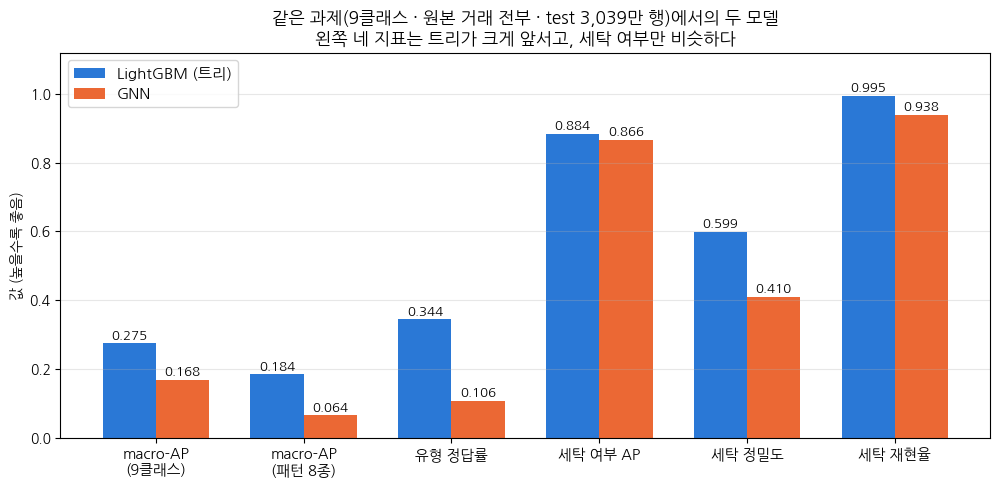

In [17]:
METS = [('macro_AP_9', 'macro-AP\n(9클래스)'), ('macro_AP_패턴8종', 'macro-AP\n(패턴 8종)'),
        ('패턴행중_유형정답률', '유형 정답률'), ('세탁여부_AP', '세탁 여부 AP'),
        ('세탁여부_argmax_정밀도', '세탁 정밀도'), ('세탁여부_argmax_재현율', '세탁 재현율')]
fig, ax = plt.subplots(figsize=(12, 5)); x = np.arange(len(METS)); w = .36
for i, (m, lab, col) in enumerate([(t, 'LightGBM (트리)', TREE), (g, 'GNN', GNN)]):
    v = [m[k] for k, _ in METS]
    ax.bar(x + (i - .5) * w, v, w, label=lab, color=col)
    for xx, vv in zip(x + (i - .5) * w, v):
        ax.text(xx, vv + .012, f'{vv:.3f}', ha='center', fontsize=9.5)
ax.set_xticks(x); ax.set_xticklabels([lab for _, lab in METS], fontsize=10.5)
ax.set_ylim(0, 1.12); ax.set_ylabel('값 (높을수록 좋음)'); ax.grid(axis='y', alpha=.3); ax.legend(fontsize=11)
ax.set_title('같은 과제(9클래스 · 원본 거래 전부 · test 3,039만 행)에서의 두 모델\n왼쪽 네 지표는 트리가 크게 앞서고, 세탁 여부만 비슷하다', fontsize=12.5)
save(fig, 'G1_지표비교.png', 'results/T10_e_트리대비_비교.csv')

## §4-2 학습 곡선 — GNN 은 내려갔고 트리는 올라갔다

GNN 은 epoch 1 이 최고였고 2·3 에서 계속 내려가 중단 규칙에 걸렸다. **선택된 모델은 epoch 1, 즉 한 번 훑은 모델이다.**
이 수치를 "GNN 의 실력"으로 읽으면 안 되는 가장 큰 이유가 이 그림이다.

GNN epoch별 val macro-AP [0.16137, 0.15434, 0.15158]
트리 최고 0.29856 @ round 180


  저장 /workspace/Final_preprocess/HI-Large_EDA/notebooks/_figs_28/G2_학습곡선.png  ← 출처 results/T10_d_GNN9_학습기록.csv · us_cmp_20260922/arms/full_w300/history.csv


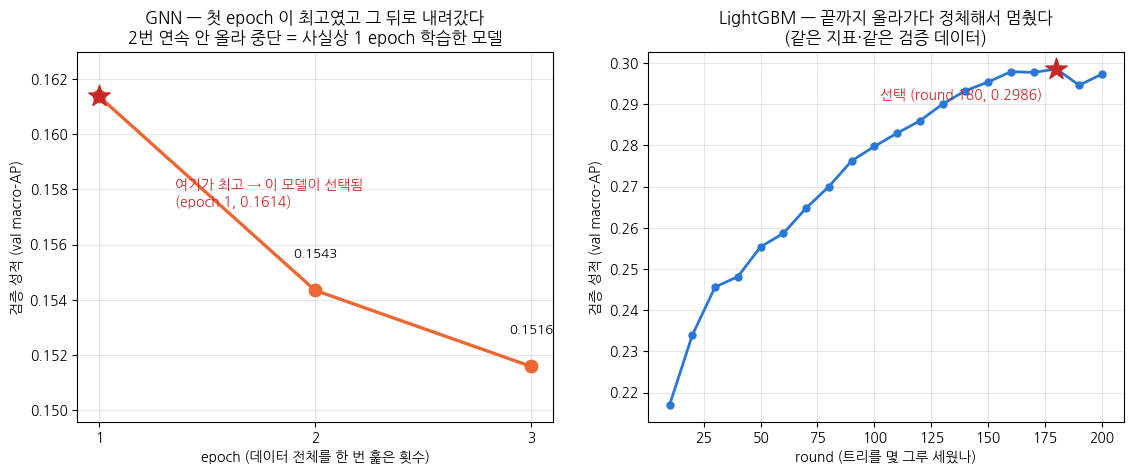

In [18]:
H = pd.read_csv(R / 'T10_d_GNN9_학습기록.csv')
TH = pd.read_csv(U / 'arms/full_w300/history.csv')
print(f'GNN epoch별 val macro-AP {H["val_macro_ap"].round(5).tolist()}')
print(f'트리 최고 {TH["val_macro_ap"].max():.5f} @ round {TH.loc[TH["val_macro_ap"].idxmax(), "trees"]}')
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]; ax.plot(H['epoch'], H['val_macro_ap'], 'o-', color=GNN, lw=2.4, ms=9)
best = H.loc[H['val_macro_ap'].idxmax()]
ax.scatter([best['epoch']], [best['val_macro_ap']], s=260, marker='*', color='#c62828', zorder=5)
ax.annotate(f"여기가 최고 → 이 모델이 선택됨\n(epoch {int(best['epoch'])}, {best['val_macro_ap']:.4f})",
            xy=(best['epoch'], best['val_macro_ap']), xytext=(1.35, best['val_macro_ap'] - .004), fontsize=10, color='#c62828')
for _, r_ in H.iterrows():
    if r_['epoch'] != best['epoch']:
        ax.text(r_['epoch'], r_['val_macro_ap'] + .0012, f"{r_['val_macro_ap']:.4f}", ha='center', fontsize=9.5)
ax.set_ylim(H['val_macro_ap'].min() - .002, H['val_macro_ap'].max() + .0016); ax.set_xticks(H['epoch'])
ax.set_xlabel('epoch (데이터 전체를 한 번 훑은 횟수)'); ax.set_ylabel('검증 성적 (val macro-AP)'); ax.grid(alpha=.3)
ax.set_title('GNN — 첫 epoch 이 최고였고 그 뒤로 내려갔다\n2번 연속 안 올라 중단 = 사실상 1 epoch 학습한 모델', fontsize=12)
ax = axes[1]; ax.plot(TH['trees'], TH['val_macro_ap'], 'o-', color=TREE, lw=2, ms=5)
sel = TH[TH['selected']]
if len(sel):
    ax.scatter(sel['trees'], sel['val_macro_ap'], s=260, marker='*', color='#c62828', zorder=5)
    ax.annotate(f"선택 (round {int(sel['trees'].iloc[0])}, {sel['val_macro_ap'].iloc[0]:.4f})",
                xy=(sel['trees'].iloc[0], sel['val_macro_ap'].iloc[0]), xytext=(-10, -22),
                textcoords='offset points', fontsize=10, color='#c62828', ha='right')
ax.set_xlabel('round (트리를 몇 그루 세웠나)'); ax.set_ylabel('검증 성적 (val macro-AP)'); ax.grid(alpha=.3)
ax.set_title('LightGBM — 끝까지 올라가다 정체해서 멈췄다\n(같은 지표·같은 검증 데이터)', fontsize=12)
save(fig, 'G2_학습곡선.png', 'results/T10_d_GNN9_학습기록.csv · us_cmp_20260922/arms/full_w300/history.csv')

## §4-3 세탁 유형 8종 각각 — 8종 전부 트리가 앞선다

클래스별 (트리 − GNN) AP 차이: {'FAN-OUT': 0.212, 'FAN-IN': 0.13, 'CYCLE': 0.098, 'SCATTER-GATHER': 0.156, 'GATHER-SCATTER': 0.095, 'BIPARTITE': 0.095, 'STACK': 0.107, 'RANDOM': 0.064}


  저장 /workspace/Final_preprocess/HI-Large_EDA/notebooks/_figs_28/G3_클래스별AP.png  ← 출처 results/T10_b_GNN9_클래스별.csv · us_cmp_20260922/results/T11b_클래스별.csv


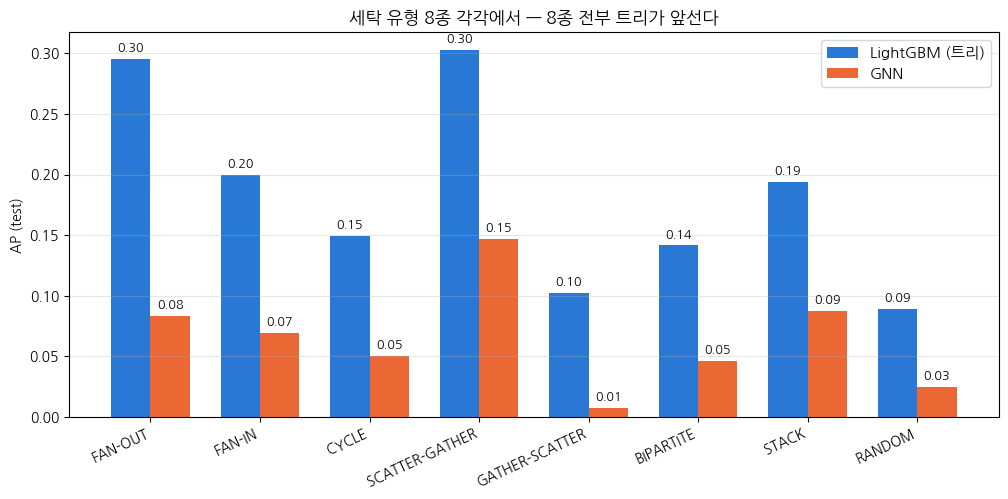

In [19]:
Cg = pd.read_csv(R / 'T10_b_GNN9_클래스별.csv'); Cg = Cg[Cg['split'] == 'test']
Ct = pd.read_csv(U / 'results/T11b_클래스별.csv'); Ct = Ct[(Ct['split'] == 'test') & (Ct['팔'] == 'full_w300')]
M = Cg[['클래스', 'AP']].merge(Ct[['클래스', 'AP']], on='클래스', suffixes=('_gnn', '_tree'))
M = M[M['클래스'] != '정상'].set_index('클래스').loc[CLASS8]
print('클래스별 (트리 − GNN) AP 차이:', (M['AP_tree'] - M['AP_gnn']).round(3).to_dict())
fig, ax = plt.subplots(figsize=(12, 5)); x = np.arange(8); w = .36
ax.bar(x - w / 2, M['AP_tree'], w, label='LightGBM (트리)', color=TREE)
ax.bar(x + w / 2, M['AP_gnn'], w, label='GNN', color=GNN)
for xx, v in zip(x - w / 2, M['AP_tree']):
    ax.text(xx, v + .006, f'{v:.2f}', ha='center', fontsize=9)
for xx, v in zip(x + w / 2, M['AP_gnn']):
    ax.text(xx, v + .006, f'{v:.2f}', ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(CLASS8, rotation=25, ha='right', fontsize=10)
ax.set_ylabel('AP (test)'); ax.grid(axis='y', alpha=.3); ax.legend(fontsize=11)
ax.set_title('세탁 유형 8종 각각에서 — 8종 전부 트리가 앞선다', fontsize=12.5)
save(fig, 'G3_클래스별AP.png', 'results/T10_b_GNN9_클래스별.csv · us_cmp_20260922/results/T11b_클래스별.csv')

## §4-4 GNN 이 무엇을 틀렸나 — 세 유형은 아예 답하지 않았다

GNN 예측 건수 {'FAN-OUT': 252, 'FAN-IN': 26576, 'CYCLE': 429, 'SCATTER-GATHER': 4671, 'GATHER-SCATTER': 24066, 'BIPARTITE': 0, 'STACK': 2, 'RANDOM': 20}
실제 건수   {'FAN-OUT': 2571, 'FAN-IN': 2323, 'CYCLE': 2250, 'SCATTER-GATHER': 4726, 'GATHER-SCATTER': 4637, 'BIPARTITE': 2216, 'STACK': 4151, 'RANDOM': 1629}


  저장 /workspace/Final_preprocess/HI-Large_EDA/notebooks/_figs_28/G4_GNN예측쏠림.png  ← 출처 results/T10_b_GNN9_클래스별.csv


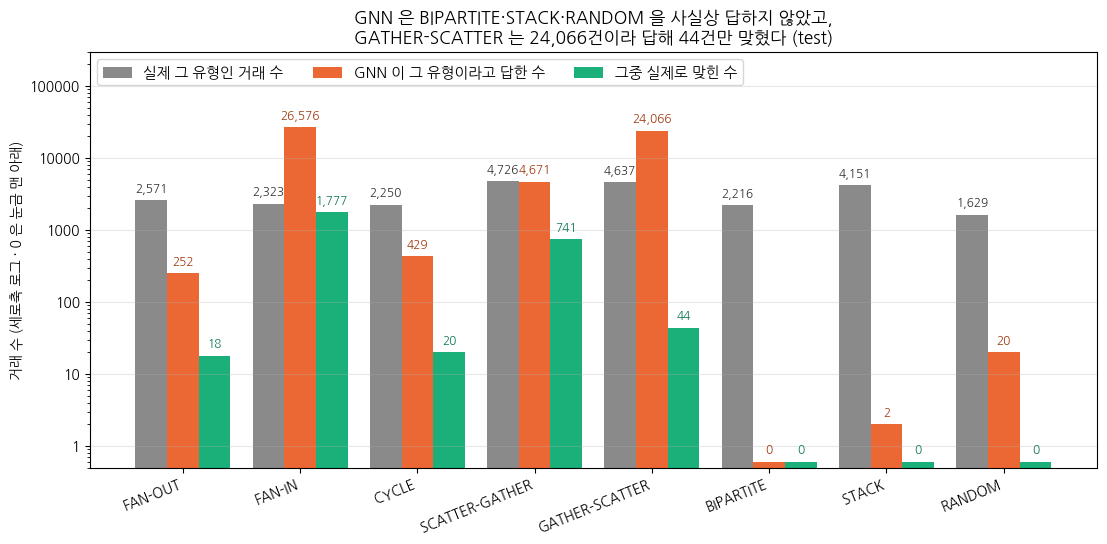

In [20]:
D = Cg[Cg['클래스'] != '정상'].set_index('클래스').loc[CLASS8]
print('GNN 예측 건수', D['예측_건수'].to_dict()); print('실제 건수  ', D['정답_건수'].to_dict())
fig, ax = plt.subplots(figsize=(13, 5.4)); x = np.arange(8); w = .27
BARS = [(D['정답_건수'], '실제 그 유형인 거래 수', '#8a8a8a'),
        (D['예측_건수'], 'GNN 이 그 유형이라고 답한 수', GNN),
        (D['맞춘_건수'], '그중 실제로 맞힌 수', '#1baf7a')]
for i, (v, lab, c) in enumerate(BARS):
    ax.bar(x + (i - 1) * w, np.clip(v, .6, None), w, label=lab, color=c)
    for xx, vv in zip(x + (i - 1) * w, v):
        ax.text(xx, max(vv, .6) * 1.3, f'{int(vv):,}', ha='center', fontsize=8.6,
                color='#333' if i == 0 else ('#a03a12' if i == 1 else '#127a55'))
ax.set_yscale('log'); ax.set_ylim(.5, 3e5)
ax.set_xticks(x); ax.set_xticklabels(CLASS8, rotation=22, ha='right', fontsize=10)
ax.set_ylabel('거래 수 (세로축 로그 · 0 은 눈금 맨 아래)'); ax.grid(axis='y', alpha=.3); ax.legend(fontsize=10.5, loc='upper left', ncol=3)
ax.set_title('GNN 은 BIPARTITE·STACK·RANDOM 을 사실상 답하지 않았고,\nGATHER-SCATTER 는 24,066건이라 답해 44건만 맞혔다 (test)', fontsize=12.5)
save(fig, 'G4_GNN예측쏠림.png', 'results/T10_b_GNN9_클래스별.csv')

## §4-5 과제를 바꾸자 결과가 갈렸다

§2(노트북 26, 세탁 행만 놓고 8종 고르기)에서는 GNN 이 트리보다 앞섰는데, §3(정상까지 섞인 원본 거래 전부)에서는 뒤집혔다.
**같은 GNN 인데 과제가 바뀌자 무너진 것**이므로, 한쪽 수치만 인용하면 안 된다.

§2 트리 0.337 / GNN 0.401   →   §3 트리 0.344 / GNN 0.106
  저장 /workspace/Final_preprocess/HI-Large_EDA/notebooks/_figs_28/G5_과제에따른차이.png  ← 출처 results/T9_트리대비_비교.csv · T10_e_트리대비_비교.csv


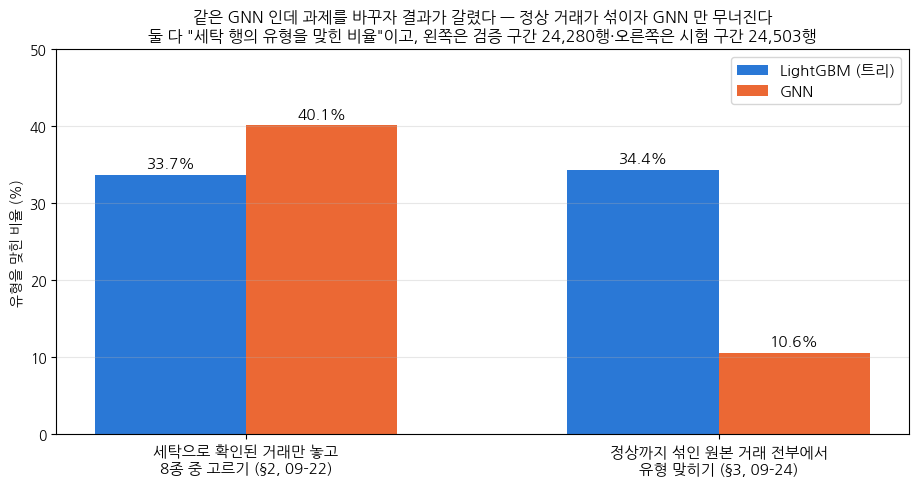

In [21]:
E3 = pd.read_csv(R / 'T9_트리대비_비교.csv')
e3 = E3[E3['구분'] == '평가 전체'].iloc[0]
pairs = [('세탁으로 확인된 거래만 놓고\n8종 중 고르기 (§2, 09-22)', e3['트리_정확도'], e3['GNN40_정확도_평균']),
         ('정상까지 섞인 원본 거래 전부에서\n유형 맞히기 (§3, 09-24)', t['패턴행중_유형정답률'], g['패턴행중_유형정답률'])]
print(f'§2 트리 {e3["트리_정확도"]:.3f} / GNN {e3["GNN40_정확도_평균"]:.3f}   →   §3 트리 {t["패턴행중_유형정답률"]:.3f} / GNN {g["패턴행중_유형정답률"]:.3f}')
fig, ax = plt.subplots(figsize=(11, 5)); x = np.arange(2); w = .32
ax.bar(x - w / 2, [p[1] * 100 for p in pairs], w, label='LightGBM (트리)', color=TREE)
ax.bar(x + w / 2, [p[2] * 100 for p in pairs], w, label='GNN', color=GNN)
for i, p in enumerate(pairs):
    ax.text(i - w / 2, p[1] * 100 + .8, f'{p[1]*100:.1f}%', ha='center', fontsize=11)
    ax.text(i + w / 2, p[2] * 100 + .8, f'{p[2]*100:.1f}%', ha='center', fontsize=11)
ax.set_xticks(x); ax.set_xticklabels([p[0] for p in pairs], fontsize=11)
ax.set_ylabel('유형을 맞힌 비율 (%)'); ax.set_ylim(0, 50); ax.grid(axis='y', alpha=.3); ax.legend(fontsize=11)
ax.set_title('같은 GNN 인데 과제를 바꾸자 결과가 갈렸다 — 정상 거래가 섞이자 GNN 만 무너진다\n'
             '둘 다 "세탁 행의 유형을 맞힌 비율"이고, 왼쪽은 검증 구간 24,280행·오른쪽은 시험 구간 24,503행', fontsize=11.5)
save(fig, 'G5_과제에따른차이.png', 'results/T9_트리대비_비교.csv · T10_e_트리대비_비교.csv')

## §4-6 요점 정리 (관찰이지 결론이 아니다)

In [22]:
pts = [
    f"test 전 항목 트리 우위 — macro-AP(9) {t['macro_AP_9']:.4f} vs {g['macro_AP_9']:.4f} · "
    f"패턴 8종 {t['macro_AP_패턴8종']:.4f} vs {g['macro_AP_패턴8종']:.4f} · 유형 정답률 {t['패턴행중_유형정답률']:.4f} vs {g['패턴행중_유형정답률']:.4f}",
    f"단 '세탁이냐 아니냐'는 비슷하다 — 세탁 여부 AP {t['세탁여부_AP']:.4f} vs {g['세탁여부_AP']:.4f}. GNN 이 못 배운 것은 탐지가 아니라 유형 구분이다.",
    f"GNN 은 제대로 학습되지 않았다 — 검증 성적이 epoch {int(best['epoch'])}({best['val_macro_ap']:.5f})에서 최고였고 그 뒤 "
    f"{' → '.join(f'{v:.5f}' for v in H.loc[H['epoch'] > best['epoch'], 'val_macro_ap'])} 로 내려가 중단됐다. 선택된 모델은 사실상 1 epoch 짜리다.",
    f"GNN 은 세 유형을 아예 답하지 않았다 — " + ' · '.join(f'{c} {int(D.loc[c, "예측_건수"]):,}건' for c in ['BIPARTITE', 'STACK', 'RANDOM'])
    + f". 반면 GATHER-SCATTER 는 {int(D.loc['GATHER-SCATTER', '예측_건수']):,}건이라 답해 {int(D.loc['GATHER-SCATTER', '맞춘_건수']):,}건만 맞혔다.",
    f"과제를 바꾸자 갈렸다 — 세탁 행만: GNN {e3['GNN40_정확도_평균']*100:.1f}% > 트리 {e3['트리_정확도']*100:.1f}% / "
    f"정상 포함: GNN {g['패턴행중_유형정답률']*100:.1f}% << 트리 {t['패턴행중_유형정답률']*100:.1f}%",
    "이 비교는 모델만 다른 비교가 아니다 — 입력 피처가 서로 다르다(맨 위 표). 순수한 'GNN vs 트리'로 인용하면 안 된다.",
]
print('=' * 92); print('  §4 요점 — GNN vs LightGBM (test · 상태 제안·미결)'); print('=' * 92)
for i, s in enumerate(pts, 1):
    print(f'{i}. {s}\n')
print('그림 5장 →', FIGS)
print('근거 문서 → /workspace/Final_preprocess/보고서_GNN_20260926/보고서_GNN_vs_LightGBM_손은총_20260926.md')

  §4 요점 — GNN vs LightGBM (test · 상태 제안·미결)
1. test 전 항목 트리 우위 — macro-AP(9) 0.2748 vs 0.1684 · 패턴 8종 0.1841 vs 0.0645 · 유형 정답률 0.3440 vs 0.1061

2. 단 '세탁이냐 아니냐'는 비슷하다 — 세탁 여부 AP 0.8844 vs 0.8659. GNN 이 못 배운 것은 탐지가 아니라 유형 구분이다.

3. GNN 은 제대로 학습되지 않았다 — 검증 성적이 epoch 1(0.16137)에서 최고였고 그 뒤 0.15434 → 0.15158 로 내려가 중단됐다. 선택된 모델은 사실상 1 epoch 짜리다.

4. GNN 은 세 유형을 아예 답하지 않았다 — BIPARTITE 0건 · STACK 2건 · RANDOM 20건. 반면 GATHER-SCATTER 는 24,066건이라 답해 44건만 맞혔다.

5. 과제를 바꾸자 갈렸다 — 세탁 행만: GNN 40.1% > 트리 33.7% / 정상 포함: GNN 10.6% << 트리 34.4%

6. 이 비교는 모델만 다른 비교가 아니다 — 입력 피처가 서로 다르다(맨 위 표). 순수한 'GNN vs 트리'로 인용하면 안 된다.

그림 5장 → /workspace/Final_preprocess/HI-Large_EDA/notebooks/_figs_28
근거 문서 → /workspace/Final_preprocess/보고서_GNN_20260926/보고서_GNN_vs_LightGBM_손은총_20260926.md
